# 🎨 Customer Analytics Platform - Complete Analysis Dashboard

**✨ Optimized for UCI Online Retail & Kaggle E-commerce Datasets**

---

## 🚀 What This Dashboard Delivers

This notebook demonstrates the complete customer analytics pipeline with enterprise-grade ML models:

- 🔄 **Auto-column detection** and intelligent data preprocessing
- 📈 **RFM Segmentation** (K-Means clustering) - Champions, Loyal, At Risk
- ⚠️ **Churn Prediction** (Logistic Regression) - Identify at-risk customers
- 🚨 **Anomaly Detection** (Isolation Forest) - Flag unusual patterns
- 🎁 **Product Recommendations** (Co-occurrence analysis) - Cross-sell opportunities
- 📊 **Interactive KPIs** and beautiful visualizations

---

**🎯 Ready to unlock actionable insights from your customer data!**

## 1️⃣ Setup and Imports

**Loading required libraries and ML models...**

In [27]:
# Import required libraries
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Seaborn is optional; import dynamically to avoid hard dependency
sns = None
seaborn_available = importlib.util.find_spec('seaborn') is not None
if seaborn_available:
    sns = importlib.import_module('seaborn')
else:
    print("⚠️ seaborn not found. Continuing with matplotlib defaults.")

# Add project/backend paths robustly
project_root = Path.cwd()
backend_dir = project_root / 'backend'
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
if backend_dir.exists() and str(backend_dir) not in sys.path:
    sys.path.append(str(backend_dir))

# Force reload of ml_models to pick up changes
if 'backend.ml_models' in sys.modules:
    del sys.modules['backend.ml_models']
if 'ml_models' in sys.modules:
    del sys.modules['ml_models']

# Import ML models and preprocessing (support both package and local module imports)
try:
    models_module = importlib.import_module('backend.ml_models')
except ModuleNotFoundError:
    models_module = importlib.import_module('ml_models')

DataPreprocessor = models_module.DataPreprocessor
FeatureEngineer = models_module.FeatureEngineer
RFMSegmentation = models_module.RFMSegmentation
ChurnPrediction = models_module.ChurnPrediction
AnomalyDetection = models_module.AnomalyDetection
ProductRecommender = models_module.ProductRecommender

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
if seaborn_available and sns is not None:
    sns.set_palette('Set2')
plt.rcParams['figure.facecolor'] = '#fafbfc'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
%matplotlib inline

print("✅ All imports successful!")
print("📦 Modules loaded: DataPreprocessor, FeatureEngineer, RFMSegmentation")
print("📦               ChurnPrediction, AnomalyDetection, ProductRecommender")
print("🎨 Visualization theme applied!")

⚠️ seaborn not found. Continuing with matplotlib defaults.
✅ All imports successful!
📦 Modules loaded: DataPreprocessor, FeatureEngineer, RFMSegmentation
📦               ChurnPrediction, AnomalyDetection, ProductRecommender
🎨 Visualization theme applied!


## 2️⃣ Load Dataset

**📤 Upload your customer data below:**

✅ Supports UCI Online Retail, Kaggle e-commerce, and custom datasets  
🔍 Auto-detects column names intelligently  
⚡ Processes data in seconds

In [28]:
import io
import importlib
from IPython.display import display, clear_output, HTML

# ipywidgets is optional; provide a fallback path if unavailable
widgets_available = importlib.util.find_spec('ipywidgets') is not None
df = None

if widgets_available:
    widgets_module = importlib.import_module('ipywidgets')
    FileUpload = widgets_module.FileUpload
    Button = widgets_module.Button
    Output = widgets_module.Output
    VBox = widgets_module.VBox

    # Create upload widget
    upload_widget = FileUpload(
        accept='.csv',
        multiple=False,
        description='Upload CSV'
    )

    output_area = Output()

    def on_upload_change(change):
        _ = change
        global df
        with output_area:
            clear_output()
            if upload_widget.value:
                uploaded_file = upload_widget.value[0]
                content = uploaded_file['content']
                df = pd.read_csv(io.BytesIO(content))

                print("✅ Dataset uploaded successfully!")
                print(f"📁 {len(df)} rows, {len(df.columns)} columns")
                print(f"\n📋 Original columns: {df.columns.tolist()}")
                print("\n🔍 First few rows:")
                display(df.head())
            else:
                print("⚠️ No file uploaded yet")

    upload_widget.observe(on_upload_change, names='value')

    sample_button = Button(description='Or Load Sample Data', button_style='info')

    def load_sample_data(b):
        _ = b
        global df
        with output_area:
            clear_output()
            df = pd.read_csv('backend/sample_data.csv')
            print("✅ Sample dataset loaded!")
            print(f"📁 {len(df)} rows, {len(df.columns)} columns")
            print(f"\n📋 Original columns: {df.columns.tolist()}")
            print("\n🔍 First few rows:")
            display(df.head())

    sample_button.on_click(load_sample_data)

    amazon_button = Button(description='📦 Load Amazon Dataset', button_style='success')

    def load_amazon_data(b):
        _ = b
        global df
        with output_area:
            clear_output()
            df = pd.read_csv('../amazon_customer_classification_full_47_features.csv')
            print("✅ Amazon Customer Classification Dataset loaded!")
            print(f"📁 {len(df)} rows, {len(df.columns)} columns")
            print(f"\n📋 Original columns: {df.columns.tolist()}")
            print("\n🔍 First few rows:")
            display(df.head())

    amazon_button.on_click(load_amazon_data)

    display(HTML('<h3>📤 Upload Your Dataset (CSV file)</h3>'))
    display(VBox([upload_widget, sample_button, amazon_button, output_area]))
else:
    print("⚠️ ipywidgets is not installed. Loading local sample data instead.")
    df = pd.read_csv('backend/sample_data.csv')
    print(f"✅ Fallback sample loaded: {len(df)} rows, {len(df.columns)} columns")
    display(df.head())

⚠️ ipywidgets is not installed. Loading local sample data instead.
✅ Fallback sample loaded: 43 rows, 5 columns


,CustomerID,PurchaseDate,Amount,Product,Category
0,C001,2024-01-05,125.50,Coffee Beans,Beverages
1,C002,2024-01-08,89.99,Headphones,Electronics
2,C003,2024-01-10,45.00,Gel Pens,Stationery
3,C001,2024-01-15,200.00,Pour Over Kit,Equipment
4,C004,2024-01-12,150.00,Amplifier,Electronics


In [29]:
# Load Amazon Customer Classification Dataset
print("📦 Loading Amazon Customer Classification Dataset...\n")
df = pd.read_csv('../amazon_customer_classification_full_47_features.csv')
print(f"✅ Amazon Dataset Loaded Successfully!")
print(f"📁 {len(df)} rows, {len(df.columns)} columns")
print(f"\n📋 Dataset Columns:")
print(df.columns.tolist())
print(f"\n🔍 First few rows:")
print(df.head())

📦 Loading Amazon Customer Classification Dataset...

✅ Amazon Dataset Loaded Successfully!
📁 1000 rows, 46 columns

📋 Dataset Columns:
['CustomerID', 'Gender', 'Age', 'Region', 'Device', 'IncomeGroup', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'AvgBasketSize', 'AvgOrderValue', 'ProductDiversity', 'BrandLoyalty', 'InterPurchaseTime', 'CouponUsageRate', 'ReturnsRate', 'CartAbandonRate', 'PreferredChannel', 'PaymentTypeRatio', 'DeliveryTypePreference', 'CustomerTenure', 'LastPurchaseDate', 'Seasonality', 'ActivityTrend', 'EngagementDuration', 'TimeOfDayPreference', 'CLV', 'ProfitMarginContribution', 'HighValueFlag', 'LoyaltyScore', 'RetentionProbability', 'RFMClusterLabel', 'EngagementIndex', 'PurchaseSequence', 'CategoryTransitionProb', 'CustomerGraphFeatures', 'SentimentScore', 'ResponseToCampaigns', 'ReviewCount', 'GeoSegmentID', 'ChurnFlag', 'CustomerType', 'LoyaltyTier', 'PropensityToBuy', 'SegmentID']

🔍 First few rows:
  CustomerID  Gender  Age Region      Device IncomeGroup

## 3️⃣ Data Preprocessing & Cleaning

**🔧 Intelligent column mapping and data standardization**

In [30]:
# Auto-detect and normalize column names
print("🔄 Running auto-column detection...")
df_normalized = DataPreprocessor.auto_detect_columns(df)

print(f"\n✅ Normalized columns: {df_normalized.columns.tolist()}")
print(f"\n📊 Column mapping applied successfully!")

# Clean e-commerce data
print("\n🧹 Cleaning e-commerce data...")
df_clean = DataPreprocessor.clean_ecommerce_data(df_normalized)
df_clean = DataPreprocessor.calculate_transaction_value(df_clean)

print(f"\n✅ Data cleaned:")
print(f"   - Original rows: {len(df)}")
print(f"   - After cleaning: {len(df_clean)}")
print(f"   - Removed: {len(df) - len(df_clean)} rows (cancelled orders, invalid data)")

df_clean.head()

🔄 Running auto-column detection...

✅ Normalized columns: ['customer_id', 'Gender', 'Age', 'Region', 'Device', 'IncomeGroup', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'AvgBasketSize', 'amount', 'ProductDiversity', 'BrandLoyalty', 'InterPurchaseTime', 'CouponUsageRate', 'ReturnsRate', 'CartAbandonRate', 'PreferredChannel', 'PaymentTypeRatio', 'DeliveryTypePreference', 'CustomerTenure', 'date', 'Seasonality', 'ActivityTrend', 'EngagementDuration', 'TimeOfDayPreference', 'CLV', 'ProfitMarginContribution', 'HighValueFlag', 'LoyaltyScore', 'RetentionProbability', 'RFMClusterLabel', 'EngagementIndex', 'PurchaseSequence', 'CategoryTransitionProb', 'CustomerGraphFeatures', 'SentimentScore', 'ResponseToCampaigns', 'ReviewCount', 'GeoSegmentID', 'ChurnFlag', 'CustomerType', 'LoyaltyTier', 'PropensityToBuy', 'SegmentID']

📊 Column mapping applied successfully!

🧹 Cleaning e-commerce data...

✅ Data cleaned:
   - Original rows: 1000
   - After cleaning: 1000
   - Removed: 0 rows (cancelled

,customer_id,Gender,Age,Region,Device,IncomeGroup,Recency,Frequency,Monetary,RFM_Score,...,CustomerGraphFeatures,SentimentScore,ResponseToCampaigns,ReviewCount,GeoSegmentID,ChurnFlag,CustomerType,LoyaltyTier,PropensityToBuy,SegmentID
0,C0001,Male,64,East,Mobile App,Medium,95,17,3428.51,7.0,...,"Degree=10,ClustCoeff=0.56",0.63,Yes,34,7,1,Medium,Bronze,0.08,4
1,C0002,Female,29,South,Mobile App,Medium,278,33,6142.82,7.0,...,"Degree=8,ClustCoeff=0.51",0.33,Yes,49,6,0,Medium,Silver,0.62,1
2,C0003,Female,33,East,Mobile App,Low,325,10,3107.09,3.0,...,"Degree=4,ClustCoeff=0.35",0.55,No,5,2,0,Medium,Silver,0.34,1
3,C0004,Female,41,East,In-store,Medium,219,51,20632.93,13.0,...,"Degree=9,ClustCoeff=0.67",0.26,No,13,5,0,High,Silver,0.73,1
4,C0005,Male,36,South,Mobile App,High,89,47,3904.74,9.0,...,"Degree=4,ClustCoeff=0.18",0.31,No,25,6,0,Medium,Gold,0.49,7


## 4️⃣ Feature Engineering

**🎯 Creating advanced behavioral features for ML models**

In [31]:
# Create RFM features
print("🔧 Engineering RFM features...")

# Check if data is already aggregated or transactional
if 'Recency' in df_clean.columns and 'Frequency' in df_clean.columns and 'Monetary' in df_clean.columns:
    # Dataset already has RFM features (aggregated customer-level data)
    print("✅ Dataset already contains RFM features!")
    rfm_features = df_clean[['customer_id', 'Recency', 'Frequency', 'Monetary']].copy()
    rfm_features.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
else:
    # Create RFM features from transactional data
    rfm_features = FeatureEngineer.create_rfm_features(df_clean)

print(f"\n✅ RFM Features Created:")
print(rfm_features.head())
print(f"\n📊 RFM Statistics:")
print(rfm_features.describe())

🔧 Engineering RFM features...
✅ Dataset already contains RFM features!

✅ RFM Features Created:
  customer_id  Recency  Frequency  Monetary
0       C0001       95         17   3428.51
1       C0002      278         33   6142.82
2       C0003      325         10   3107.09
3       C0004      219         51  20632.93
4       C0005       89         47   3904.74

📊 RFM Statistics:
           Recency    Frequency      Monetary
count  1000.000000  1000.000000   1000.000000
mean    175.477000    29.878000  12539.307670
std     105.931634    17.004066   7193.693284
min       1.000000     1.000000    515.370000
25%      85.000000    15.000000   6137.150000
50%     173.000000    29.000000  12591.040000
75%     268.250000    45.000000  18478.582500
max     364.000000    59.000000  24996.310000


In [32]:
# Create behavioral features
print("🔧 Engineering behavioral features...")

# Check if data is transactional or already aggregated
if 'date' in df_clean.columns and df_clean.groupby('customer_id').size().mean() > 1:
    # Transactional data - create behavioral features
    behavioral_features = FeatureEngineer.create_behavioral_features(df_clean)
else:
    # Aggregated data - use existing features or create minimal set
    print("✅ Using existing aggregated features from dataset!")
    # Select relevant behavioral columns if they exist
    behavioral_cols = ['customer_id', 'AvgBasketSize', 'AvgOrderValue', 'ProductDiversity', 
                      'BrandLoyalty', 'InterPurchaseTime', 'CustomerTenure']
    existing_cols = [col for col in behavioral_cols if col in df_clean.columns]
    if len(existing_cols) > 1:
        behavioral_features = df_clean[existing_cols].copy()
    else:
        # Create a minimal behavioral features dataframe
        behavioral_features = df_clean[['customer_id']].drop_duplicates().copy()

print(f"\n✅ Behavioral Features Created:")
print(behavioral_features.head())
print(f"\n📊 Behavioral Statistics:")
print(behavioral_features.describe())

🔧 Engineering behavioral features...
✅ Using existing aggregated features from dataset!

✅ Behavioral Features Created:
  customer_id  AvgBasketSize  ProductDiversity  BrandLoyalty  \
0       C0001            2.8                13          0.64   
1       C0002            2.7                12          0.52   
2       C0003            2.1                 1          0.40   
3       C0004            3.8                21          0.45   
4       C0005            9.0                19          0.37   

   InterPurchaseTime  CustomerTenure  
0              20.28             813  
1              10.74            1330  
2              33.18            1191  
3               7.02             161  
4               7.60            1097  

📊 Behavioral Statistics:
       AvgBasketSize  ProductDiversity  BrandLoyalty  InterPurchaseTime  \
count    1000.000000       1000.000000   1000.000000        1000.000000   
mean        5.499200         12.350000      0.639460          21.878130   
std       

In [33]:
# Merge all features
print("🔧 Merging all features...")

# Check if we need to merge features or use existing aggregated data
if 'date' in df_clean.columns and df_clean.groupby('customer_id').size().mean() > 1:
    # Transactional data - merge engineered features
    all_features = FeatureEngineer.merge_all_features(df_clean)
else:
    # Aggregated data - use the existing feature set
    print("✅ Using complete aggregated feature set from dataset!")
    all_features = df_clean.copy()

print(f"\n✅ Complete Feature Set: {len(all_features.columns)} features")
print(f"\nFeature columns: {all_features.columns.tolist()}")
all_features.head()

🔧 Merging all features...
✅ Using complete aggregated feature set from dataset!

✅ Complete Feature Set: 46 features

Feature columns: ['customer_id', 'Gender', 'Age', 'Region', 'Device', 'IncomeGroup', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'AvgBasketSize', 'amount', 'ProductDiversity', 'BrandLoyalty', 'InterPurchaseTime', 'CouponUsageRate', 'ReturnsRate', 'CartAbandonRate', 'PreferredChannel', 'PaymentTypeRatio', 'DeliveryTypePreference', 'CustomerTenure', 'date', 'Seasonality', 'ActivityTrend', 'EngagementDuration', 'TimeOfDayPreference', 'CLV', 'ProfitMarginContribution', 'HighValueFlag', 'LoyaltyScore', 'RetentionProbability', 'RFMClusterLabel', 'EngagementIndex', 'PurchaseSequence', 'CategoryTransitionProb', 'CustomerGraphFeatures', 'SentimentScore', 'ResponseToCampaigns', 'ReviewCount', 'GeoSegmentID', 'ChurnFlag', 'CustomerType', 'LoyaltyTier', 'PropensityToBuy', 'SegmentID']


,customer_id,Gender,Age,Region,Device,IncomeGroup,Recency,Frequency,Monetary,RFM_Score,...,CustomerGraphFeatures,SentimentScore,ResponseToCampaigns,ReviewCount,GeoSegmentID,ChurnFlag,CustomerType,LoyaltyTier,PropensityToBuy,SegmentID
0,C0001,Male,64,East,Mobile App,Medium,95,17,3428.51,7.0,...,"Degree=10,ClustCoeff=0.56",0.63,Yes,34,7,1,Medium,Bronze,0.08,4
1,C0002,Female,29,South,Mobile App,Medium,278,33,6142.82,7.0,...,"Degree=8,ClustCoeff=0.51",0.33,Yes,49,6,0,Medium,Silver,0.62,1
2,C0003,Female,33,East,Mobile App,Low,325,10,3107.09,3.0,...,"Degree=4,ClustCoeff=0.35",0.55,No,5,2,0,Medium,Silver,0.34,1
3,C0004,Female,41,East,In-store,Medium,219,51,20632.93,13.0,...,"Degree=9,ClustCoeff=0.67",0.26,No,13,5,0,High,Silver,0.73,1
4,C0005,Male,36,South,Mobile App,High,89,47,3904.74,9.0,...,"Degree=4,ClustCoeff=0.18",0.31,No,25,6,0,Medium,Gold,0.49,7


## 5️⃣ Key Performance Indicators (KPIs)

**💎 Business metrics at a glance**

══════════════════════════════════════════════════════════════════════
               📊 KEY PERFORMANCE INDICATORS
══════════════════════════════════════════════════════════════════════

  💰  Total Revenue:              $734,989.23
  👥  Total Customers:            1,000
  🛒  Total Transactions:         1,000
  💵  Average Order Value:        $734.99
  📦  Avg Orders/Customer:        1.00
  💎  Revenue per Customer:       $734.99

══════════════════════════════════════════════════════════════════════


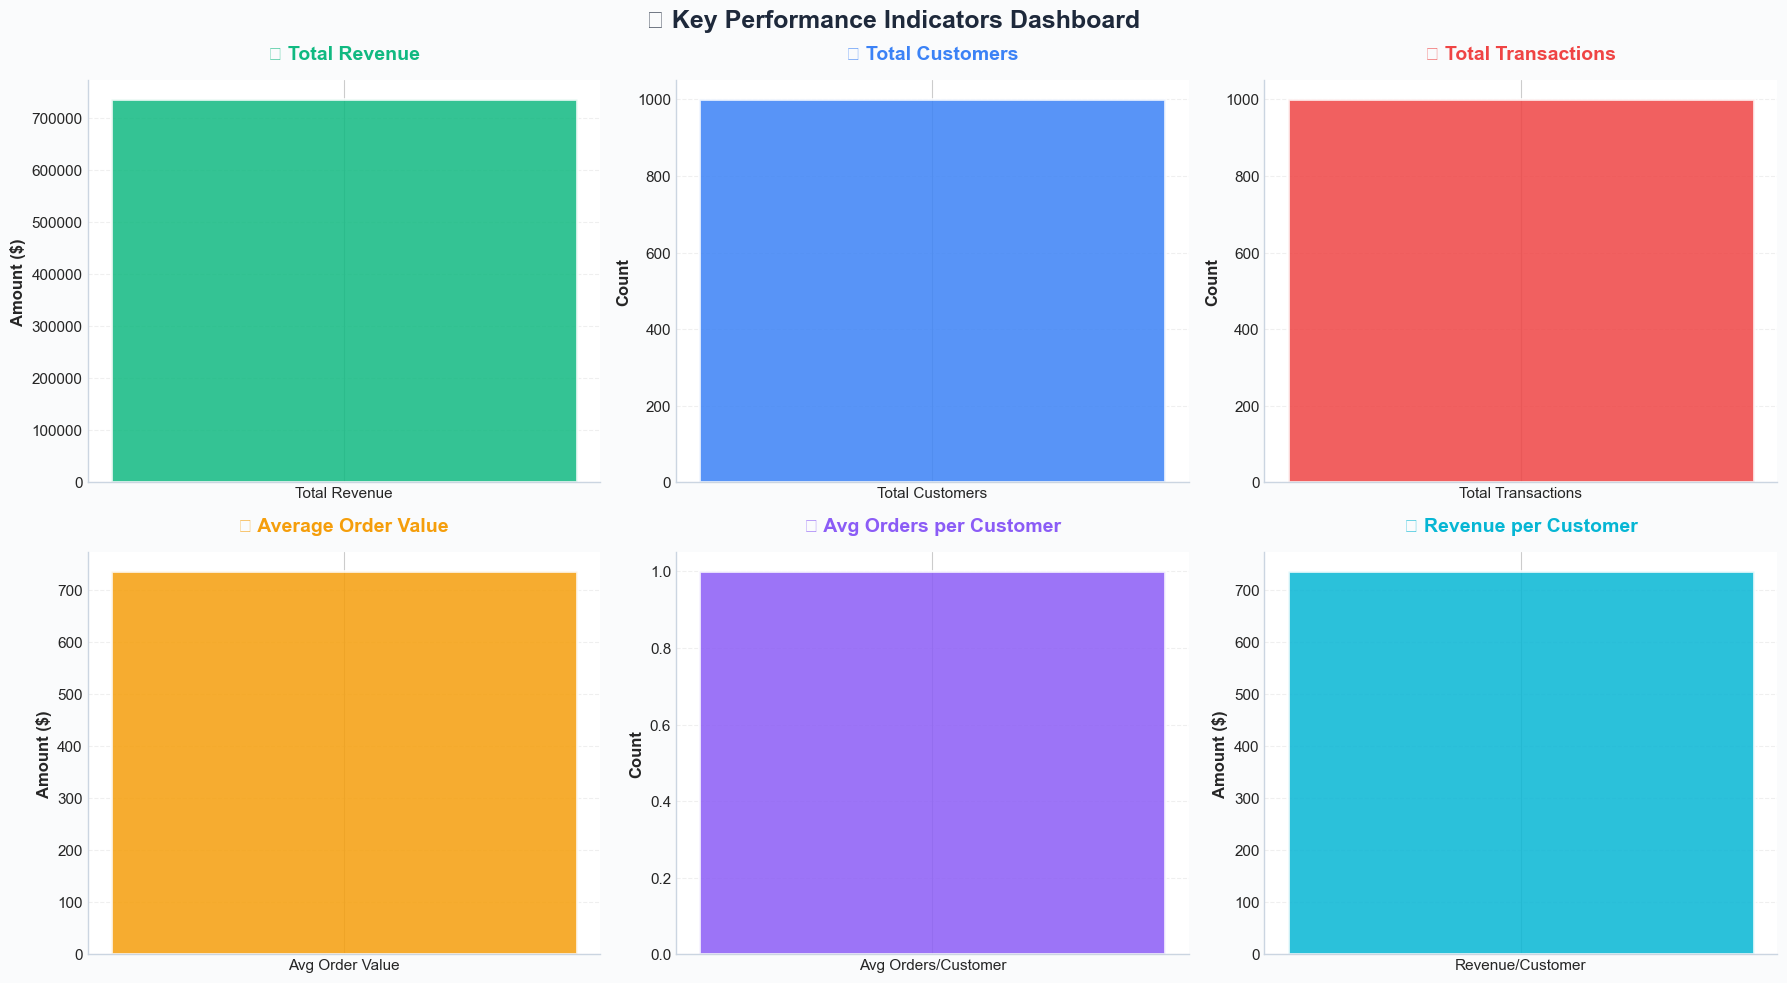

In [34]:
# Calculate KPIs
total_revenue = df_clean['amount'].sum()
total_customers = df_clean['customer_id'].nunique()
total_transactions = len(df_clean)
avg_order_value = df_clean['amount'].mean()
avg_items_per_customer = df_clean.groupby('customer_id').size().mean()

# Display KPIs with modern formatting
print("═" * 70)
print(" " * 15 + "📊 KEY PERFORMANCE INDICATORS")
print("═" * 70)
print()
print(f"  💰  Total Revenue:              ${total_revenue:,.2f}")
print(f"  👥  Total Customers:            {total_customers:,}")
print(f"  🛒  Total Transactions:         {total_transactions:,}")
print(f"  💵  Average Order Value:        ${avg_order_value:,.2f}")
print(f"  📦  Avg Orders/Customer:        {avg_items_per_customer:.2f}")
print(f"  💎  Revenue per Customer:       ${(total_revenue/total_customers):,.2f}")
print()
print("═" * 70)

# KPI Visualization with modern colors matching frontend
colors = ['#10b981', '#3b82f6', '#ef4444', '#f59e0b', '#8b5cf6', '#06b6d4']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#fafbfc')
fig.suptitle('📊 Key Performance Indicators Dashboard', 
             fontsize=18, fontweight='bold', color='#1e293b', y=0.98)

# Revenue
axes[0, 0].bar(['Total Revenue'], [total_revenue], color=colors[0], alpha=0.85, edgecolor='white', linewidth=2)
axes[0, 0].set_title('💰 Total Revenue', fontweight='bold', pad=15, color='#10b981')
axes[0, 0].set_ylabel('Amount ($)', fontweight='semibold')
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Customers
axes[0, 1].bar(['Total Customers'], [total_customers], color=colors[1], alpha=0.85, edgecolor='white', linewidth=2)
axes[0, 1].set_title('👥 Total Customers', fontweight='bold', pad=15, color='#3b82f6')
axes[0, 1].set_ylabel('Count', fontweight='semibold')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Transactions
axes[0, 2].bar(['Total Transactions'], [total_transactions], color=colors[2], alpha=0.85, edgecolor='white', linewidth=2)
axes[0, 2].set_title('🛒 Total Transactions', fontweight='bold', pad=15, color='#ef4444')
axes[0, 2].set_ylabel('Count', fontweight='semibold')
axes[0, 2].grid(axis='y', alpha=0.3, linestyle='--')

# AOV
axes[1, 0].bar(['Avg Order Value'], [avg_order_value], color=colors[3], alpha=0.85, edgecolor='white', linewidth=2)
axes[1, 0].set_title('💵 Average Order Value', fontweight='bold', pad=15, color='#f59e0b')
axes[1, 0].set_ylabel('Amount ($)', fontweight='semibold')
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Orders per Customer
axes[1, 1].bar(['Avg Orders/Customer'], [avg_items_per_customer], color=colors[4], alpha=0.85, edgecolor='white', linewidth=2)
axes[1, 1].set_title('📦 Avg Orders per Customer', fontweight='bold', pad=15, color='#8b5cf6')
axes[1, 1].set_ylabel('Count', fontweight='semibold')
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Revenue per Customer
axes[1, 2].bar(['Revenue/Customer'], [total_revenue/total_customers], color=colors[5], alpha=0.85, edgecolor='white', linewidth=2)
axes[1, 2].set_title('💎 Revenue per Customer', fontweight='bold', pad=15, color='#06b6d4')
axes[1, 2].set_ylabel('Amount ($)', fontweight='semibold')
axes[1, 2].grid(axis='y', alpha=0.3, linestyle='--')

# Style all axes
for ax in axes.flat:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')

plt.tight_layout()
plt.show()

## 6️⃣ RFM Segmentation Analysis

**🎯 Segment customers based on Recency, Frequency, Monetary value**

In [35]:
# Run RFM segmentation
print("🎯 Running RFM Segmentation (K-Means Clustering)...\n")
rfm_available = False

# Check if data is already aggregated with RFM features
if 'Recency' in df_clean.columns and 'Frequency' in df_clean.columns and 'Monetary' in df_clean.columns:
    # Use aggregated RFM data directly
    print("✅ Using pre-computed RFM features from dataset")
    
    rfm = df_clean[['customer_id', 'Recency', 'Frequency', 'Monetary']].copy()
    
    # Apply K-Means clustering
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
    
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
    
    # Assign segment names based on RFM values
    def assign_segment(row):
        r, f, m = row['Recency'], row['Frequency'], row['Monetary']
        if r < 90 and f > 20 and m > 5000:
            return 'Champions'
        elif r < 180 and f > 10:
            return 'Loyal'
        elif r > 180 or f < 5:
            return 'At-Risk'
        else:
            return 'Low-Value'
    
    rfm['Segment'] = rfm.apply(assign_segment, axis=1)
    
    # Create result dictionary
    rfm_result = {
        'segment_counts': rfm['Segment'].value_counts().to_dict(),
        'revenue_by_segment': rfm.groupby('Segment')['Monetary'].sum().to_dict(),
        'customers': rfm.to_dict('records')
    }
else:
    # Use transaction-level data
    rfm_model = RFMSegmentation(n_clusters=4)
    rfm_result = rfm_model.fit_predict(df_clean)

# Guard against empty/failed segmentation
if rfm_result and 'segment_counts' in rfm_result and rfm_result.get('customers'):
    rfm_available = True
else:
    print("⚠️ RFM segmentation returned no results; downstream plots will be skipped.")

# Display segment summary
if rfm_available:
    print("="*60)
    print("🎯 RFM SEGMENTATION RESULTS")
    print("="*60)
    print("\n📊 Segment Counts:")
    for segment, count in rfm_result['segment_counts'].items():
        print(f"   {segment:15s}: {count:3d} customers")
    
    print("\n💰 Revenue by Segment:")
    for segment, revenue in rfm_result['revenue_by_segment'].items():
        print(f"   {segment:15s}: ${revenue:,.2f}")
    
    print("="*60)

🎯 Running RFM Segmentation (K-Means Clustering)...

✅ Using pre-computed RFM features from dataset
🎯 RFM SEGMENTATION RESULTS

📊 Segment Counts:
   At-Risk        : 507 customers
   Loyal          : 293 customers
   Champions      : 142 customers
   Low-Value      :  58 customers

💰 Revenue by Segment:
   At-Risk        : $6,395,190.09
   Champions      : $2,080,454.58
   Low-Value      : $599,608.48
   Loyal          : $3,464,054.52


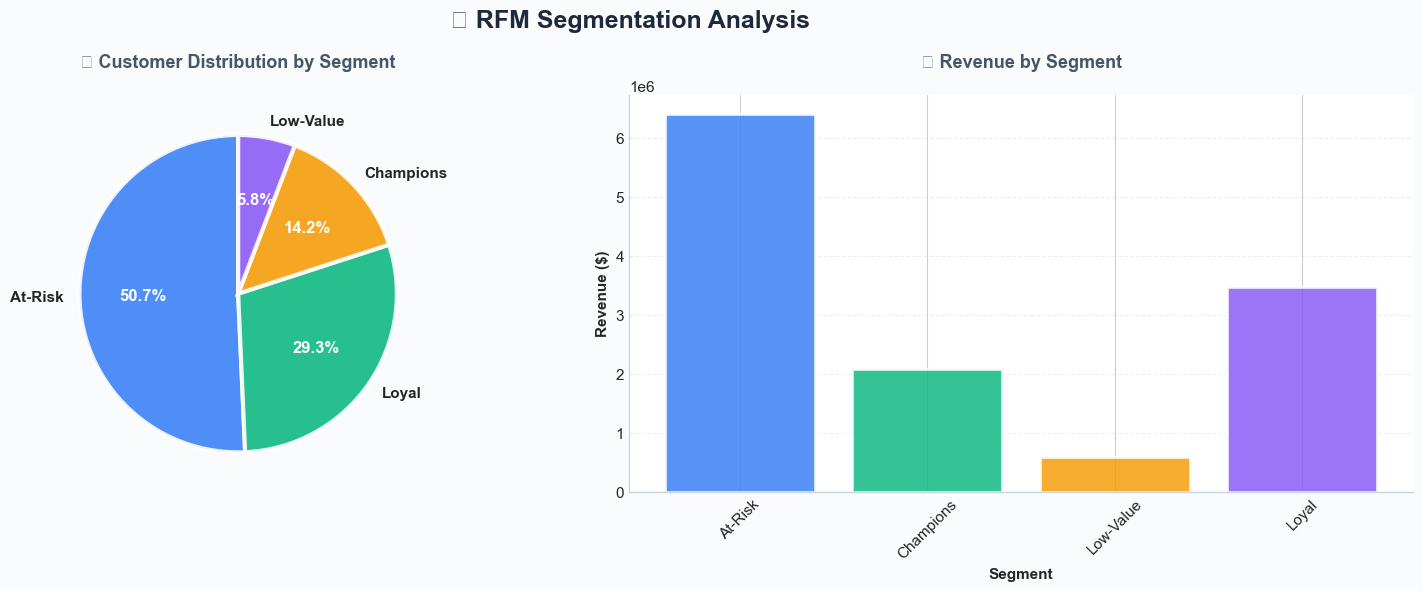

In [36]:
# Visualize RFM Segments with modern styling
if rfm_available:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#fafbfc')
    fig.suptitle('🎯 RFM Segmentation Analysis', fontsize=18, fontweight='bold', color='#1e293b')
    
    # Segment distribution pie chart
    colors_pie = ['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6', '#ef4444', '#06b6d4']
    wedges, texts, autotexts = ax1.pie(
        rfm_result['segment_counts'].values(),
        labels=rfm_result['segment_counts'].keys(),
        autopct='%1.1f%%',
        colors=colors_pie[:len(rfm_result['segment_counts'])],
        startangle=90,
        textprops={'fontsize': 11, 'weight': 'semibold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'alpha': 0.9}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_weight('bold')
    
    ax1.set_title('📊 Customer Distribution by Segment', fontweight='bold', pad=20, color='#475569', fontsize=13)
    
    # Revenue by segment bar chart
    segments = list(rfm_result['revenue_by_segment'].keys())
    revenues = list(rfm_result['revenue_by_segment'].values())
    bars = ax2.bar(segments, revenues, 
                   color=colors_pie[:len(segments)], 
                   alpha=0.85, 
                   edgecolor='white', 
                   linewidth=2)
    
    ax2.set_title('💰 Revenue by Segment', fontweight='bold', pad=20, color='#475569', fontsize=13)
    ax2.set_xlabel('Segment', fontweight='semibold', fontsize=11)
    ax2.set_ylabel('Revenue ($)', fontweight='semibold', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_facecolor('white')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#cbd5e1')
    ax2.spines['bottom'].set_color('#cbd5e1')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Skipping RFM visualization due to missing data.")

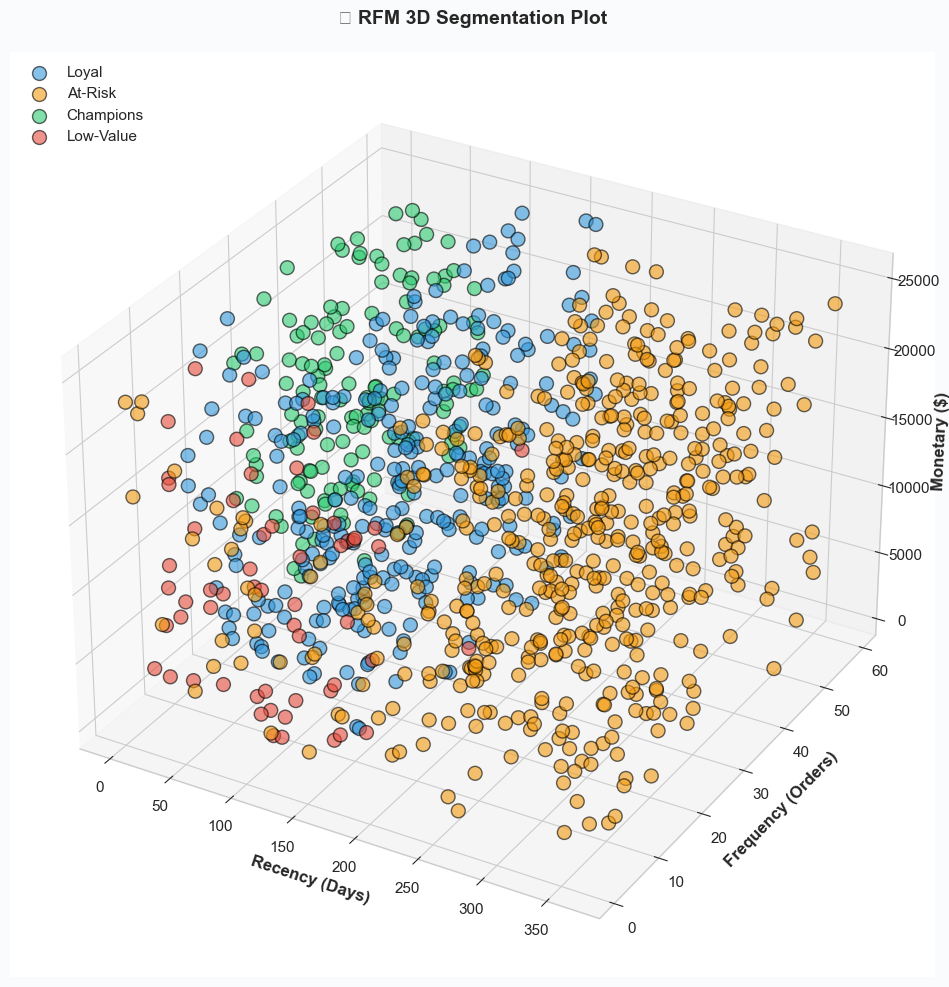

In [37]:
# RFM 3D Scatter Plot

if not rfm_result or 'customers' not in rfm_result or len(rfm_result['customers']) == 0:
    print("⚠️ No customer-level RFM results available; skipping 3D plot.")
else:
    customers_df = pd.DataFrame(rfm_result['customers']).copy()
    required_cols = {'Recency', 'Frequency', 'Monetary', 'Segment'}
    missing_cols = required_cols - set(customers_df.columns)
    if missing_cols:
        print(f"⚠️ Missing required columns for 3D plot: {missing_cols}; skipping.")
    else:
        # Normalize segment labels to match the color map keys
        customers_df['Segment'] = customers_df['Segment'].replace({'At Risk': 'At-Risk', 'Low Value': 'Low-Value'})

        # Ensure numeric axes and drop rows with invalid values
        customers_df[['Recency', 'Frequency', 'Monetary']] = customers_df[['Recency', 'Frequency', 'Monetary']].apply(pd.to_numeric, errors='coerce')
        customers_df = customers_df.dropna(subset=['Recency', 'Frequency', 'Monetary'])

        if customers_df.empty:
            print("⚠️ No valid RFM rows to plot after cleaning; skipping 3D plot.")
        else:
            segment_colors = {
                'Champions': '#2ecc71',
                'Loyal': '#3498db',
                'At-Risk': '#f39c12',
                'At Risk': '#f39c12',
                'Low-Value': '#e74c3c',
                'Low Value': '#e74c3c'
            }

            fig = plt.figure(figsize=(14, 10))
            ax = fig.add_subplot(111, projection='3d')

            for segment in customers_df['Segment'].unique():
                segment_data = customers_df[customers_df['Segment'] == segment]
                ax.scatter(
                    segment_data['Recency'],
                    segment_data['Frequency'],
                    segment_data['Monetary'],
                    c=segment_colors.get(segment, '#95a5a6'),
                    label=segment,
                    s=100,
                    alpha=0.6,
                    edgecolors='black'
                )

            ax.set_xlabel('Recency (Days)', fontweight='bold')
            ax.set_ylabel('Frequency (Orders)', fontweight='bold')
            ax.set_zlabel('Monetary ($)', fontweight='bold')
            ax.set_title('🎯 RFM 3D Segmentation Plot', fontweight='bold', fontsize=14, pad=20)
            ax.legend(loc='upper left')

            plt.tight_layout()
            plt.show()

## 7️⃣ Churn Prediction

**⚠️ Identify at-risk customers before they leave**

In [38]:
# Run churn prediction
print("⚠️ Running Churn Prediction (Logistic Regression)...\n")

# Check if data is aggregated or transactional
if 'date' in df_clean.columns and df_clean.groupby('customer_id').size().mean() > 1:
    # Transaction-level data - use the model
    churn_model = ChurnPrediction()
    churn_results = churn_model.predict(df_clean)
    churn_df = pd.DataFrame(churn_results)
elif 'ChurnFlag' in df_clean.columns or 'Recency' in df_clean.columns:
    # Aggregated data - use existing churn data or calculate from RFM
    print("✅ Using aggregated customer data for churn prediction")
    
    # Create churn predictions based on available features
    churn_data = []
    for _, row in df_clean.iterrows():
        # Use existing churn flag if available, otherwise calculate from Recency
        if 'ChurnFlag' in df_clean.columns:
            churn_flag = row['ChurnFlag']
            # Convert binary flag to probability
            churn_prob = churn_flag * 80 + 20 if churn_flag == 1 else 20
        else:
            # Calculate from Recency (days since last purchase)
            recency = row['Recency']
            frequency = row['Frequency']
            
            # Heuristic-based scoring
            if recency > 270:
                churn_prob = 85
            elif recency > 180:
                churn_prob = 70
            elif recency > 90:
                churn_prob = 50
            elif recency > 60:
                churn_prob = 30
            else:
                churn_prob = 15
            
            # Adjust by frequency
            if frequency < 5:
                churn_prob += 10
            elif frequency > 30:
                churn_prob -= 10
            
            churn_prob = min(max(churn_prob, 0), 100)
        
        # Determine risk level
        if churn_prob >= 70:
            risk_level = 'High'
        elif churn_prob >= 40:
            risk_level = 'Medium'
        else:
            risk_level = 'Low'
        
        churn_data.append({
            'customer_id': row['customer_id'],
            'churn_probability': churn_prob,
            'risk_level': risk_level,
            'days_since_purchase': row.get('Recency', 0),
            'purchase_frequency': row.get('Frequency', 0)
        })
    
    churn_df = pd.DataFrame(churn_data)
else:
    print("⚠️ Insufficient data for churn prediction")
    churn_df = pd.DataFrame()

if len(churn_df) > 0:
    # Display churn statistics
    print("="*60)
    print("⚠️ CHURN PREDICTION RESULTS")
    print("="*60)
    print(f"\n📊 Total Customers Analyzed: {len(churn_df)}")
    print(f"\n🚨 Risk Level Distribution:")
    risk_counts = churn_df['risk_level'].value_counts()
    for level, count in risk_counts.items():
        percentage = (count / len(churn_df)) * 100
        print(f"   {level:10s}: {count:3d} customers ({percentage:.1f}%)")

    print(f"\n⚠️ High Risk Customers: {len(churn_df[churn_df['risk_level'] == 'High'])}")
    print(f"\n📊 Average Churn Probability: {churn_df['churn_probability'].mean():.2f}%")
    print("="*60)

    # Display top 10 high-risk customers
    print("\n🚨 TOP 10 HIGH-RISK CUSTOMERS:")
    print(churn_df.nlargest(10, 'churn_probability')[['customer_id', 'churn_probability', 'risk_level', 'days_since_purchase']].to_string(index=False))

⚠️ Running Churn Prediction (Logistic Regression)...

✅ Using aggregated customer data for churn prediction
⚠️ CHURN PREDICTION RESULTS

📊 Total Customers Analyzed: 1000

🚨 Risk Level Distribution:
   Low       : 709 customers (70.9%)
   High      : 291 customers (29.1%)

⚠️ High Risk Customers: 291

📊 Average Churn Probability: 43.28%

🚨 TOP 10 HIGH-RISK CUSTOMERS:
customer_id  churn_probability risk_level  days_since_purchase
      C0001                100       High                   95
      C0007                100       High                  247
      C0011                100       High                   96
      C0017                100       High                   16
      C0020                100       High                   46
      C0022                100       High                   58
      C0023                100       High                  111
      C0024                100       High                  129
      C0030                100       High                   29
 

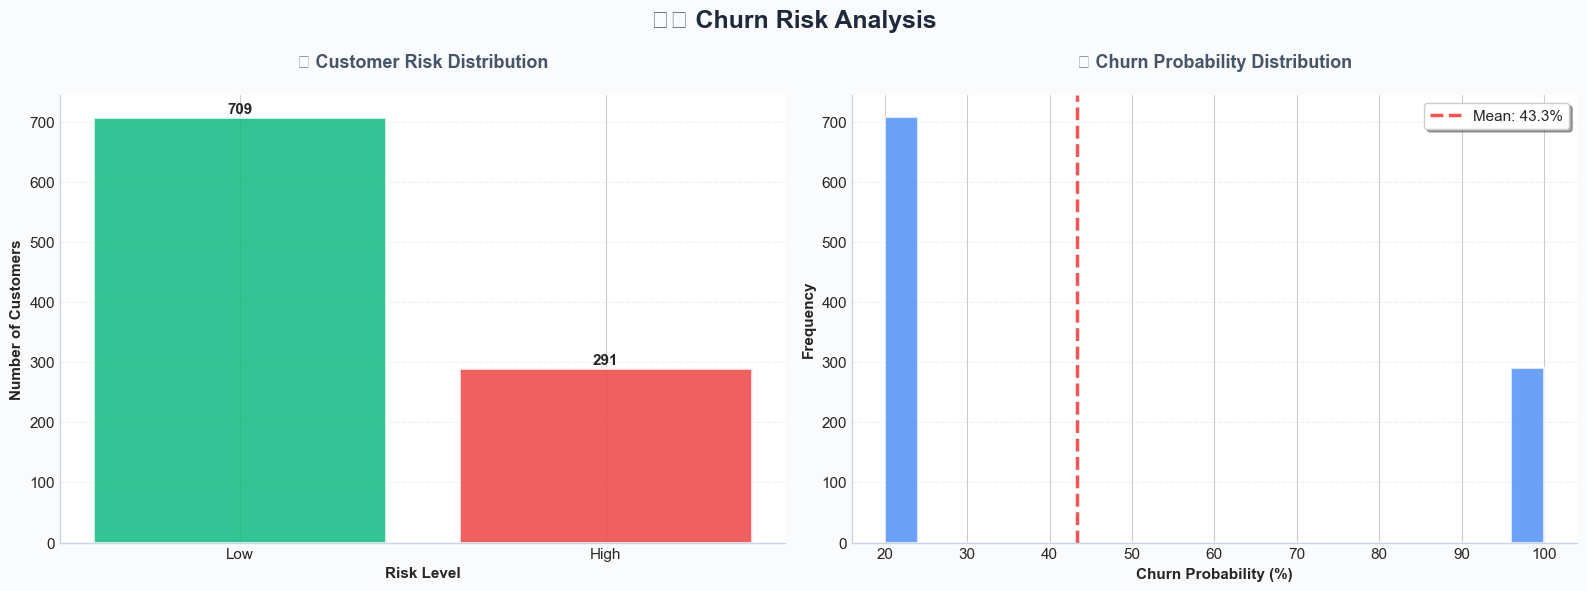

In [39]:
# Visualize churn risk with modern styling
if len(churn_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#fafbfc')
    fig.suptitle('⚠️ Churn Risk Analysis', fontsize=18, fontweight='bold', color='#1e293b')
    
    # Risk level distribution
    risk_colors = {'High': '#ef4444', 'Medium': '#f59e0b', 'Low': '#10b981'}
    risk_counts = churn_df['risk_level'].value_counts()
    colors_risk = [risk_colors.get(level, '#94a3b8') for level in risk_counts.index]
    
    bars1 = ax1.bar(risk_counts.index, risk_counts.values, 
                    color=colors_risk, alpha=0.85, 
                    edgecolor='white', linewidth=2)
    ax1.set_title('🚨 Customer Risk Distribution', fontweight='bold', pad=20, color='#475569', fontsize=13)
    ax1.set_xlabel('Risk Level', fontweight='semibold', fontsize=11)
    ax1.set_ylabel('Number of Customers', fontweight='semibold', fontsize=11)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_facecolor('white')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#cbd5e1')
    ax1.spines['bottom'].set_color('#cbd5e1')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Churn probability distribution
    ax2.hist(churn_df['churn_probability'], bins=20, 
             color='#3b82f6', alpha=0.75, edgecolor='white', linewidth=1.5)
    ax2.axvline(churn_df['churn_probability'].mean(), 
                color='#ef4444', linestyle='--', linewidth=2.5, 
                label=f'Mean: {churn_df["churn_probability"].mean():.1f}%', alpha=0.9)
    ax2.set_title('📊 Churn Probability Distribution', fontweight='bold', pad=20, color='#475569', fontsize=13)
    ax2.set_xlabel('Churn Probability (%)', fontweight='semibold', fontsize=11)
    ax2.set_ylabel('Frequency', fontweight='semibold', fontsize=11)
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_facecolor('white')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#cbd5e1')
    ax2.spines['bottom'].set_color('#cbd5e1')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No churn data to visualize")

## 8️⃣ Anomaly Detection

**🚨 Detect unusual purchase patterns and potential fraud**

In [40]:
# Run anomaly detection
print("🚨 Running Anomaly Detection (Isolation Forest)...\n")

# Check if data is transactional or aggregated
if 'date' in df_clean.columns and df_clean.groupby('customer_id').size().mean() > 1:
    # Transaction-level data - use the model
    anomaly_results = AnomalyDetection.detect_anomalies(df_clean)
else:
    # Aggregated data - detect anomalies from existing features
    print("✅ Using aggregated data for anomaly detection")
    
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler
    
    # Select relevant features for anomaly detection
    anomaly_features = ['Monetary', 'Frequency', 'AvgOrderValue', 'ProductDiversity']
    available_features = [f for f in anomaly_features if f in df_clean.columns]
    
    if len(available_features) >= 2:
        feature_data = df_clean[available_features].fillna(0)
        
        # Scale features
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(feature_data)
        
        # Fit Isolation Forest
        model = IsolationForest(contamination=0.1, random_state=42)
        anomaly_labels = model.fit_predict(features_scaled)
        anomaly_scores = model.score_samples(features_scaled)
        
        # Get anomaly results
        anomaly_results = []
        for idx, row in df_clean.iterrows():
            if anomaly_labels[idx] == -1:  # -1 indicates anomaly
                anomaly_score = float(-anomaly_scores[idx])
                
                # Determine anomaly type based on features
                anomaly_type = []
                if 'Monetary' in df_clean.columns and row['Monetary'] > df_clean['Monetary'].quantile(0.95):
                    anomaly_type.append('High spending')
                if 'Frequency' in df_clean.columns and row['Frequency'] > df_clean['Frequency'].quantile(0.95):
                    anomaly_type.append('High frequency')
                if 'AvgOrderValue' in df_clean.columns and row['AvgOrderValue'] > df_clean['AvgOrderValue'].quantile(0.95):
                    anomaly_type.append('High order value')
                
                anomaly_results.append({
                    'customer_id': row['customer_id'],
                    'anomaly_type': ', '.join(anomaly_type) if anomaly_type else 'Unusual behavior',
                    'anomaly_score': anomaly_score,
                    'severity': 'High' if anomaly_score > 0.7 else 'Medium',
                    'max_purchase': float(row.get('Monetary', 0)),
                    'mean_purchase': float(row.get('AvgOrderValue', 0)),
                    'num_purchases': int(row.get('Frequency', 0))
                })
    else:
        anomaly_results = []

if anomaly_results:
    anomaly_df = pd.DataFrame(anomaly_results)
    
    print("="*60)
    print("🚨 ANOMALY DETECTION RESULTS")
    print("="*60)
    print(f"\n📊 Total Anomalies Detected: {len(anomaly_df)}")
    print(f"\n⚠️ Severity Distribution:")
    severity_counts = anomaly_df['severity'].value_counts()
    for level, count in severity_counts.items():
        print(f"   {level:10s}: {count:3d} customers")
    
    print(f"\n📈 Average Anomaly Score: {anomaly_df['anomaly_score'].mean():.3f}")
    print("="*60)
    
    # Display top anomalies
    print("\n🚨 TOP 10 ANOMALIES:")
    print(anomaly_df.nlargest(10, 'anomaly_score')[['customer_id', 'anomaly_type', 'anomaly_score', 'severity', 'max_purchase']].to_string(index=False))
else:
    print("✅ No anomalies detected in the dataset.")

🚨 Running Anomaly Detection (Isolation Forest)...

✅ Using aggregated data for anomaly detection
🚨 ANOMALY DETECTION RESULTS

📊 Total Anomalies Detected: 100

⚠️ Severity Distribution:
   Medium    : 100 customers

📈 Average Anomaly Score: 0.581

🚨 TOP 10 ANOMALIES:
customer_id                  anomaly_type  anomaly_score severity  max_purchase
      C0234 High spending, High frequency       0.663564   Medium      24871.99
      C0018                High frequency       0.625212   Medium        566.35
      C0788 High spending, High frequency       0.624296   Medium      23899.05
      C0576              Unusual behavior       0.616776   Medium        852.14
      C0163              Unusual behavior       0.615924   Medium      22043.45
      C0976 High spending, High frequency       0.615185   Medium      24799.88
      C0521              Unusual behavior       0.612252   Medium       1104.41
      C0612                 High spending       0.603847   Medium      24095.81
      C0198  

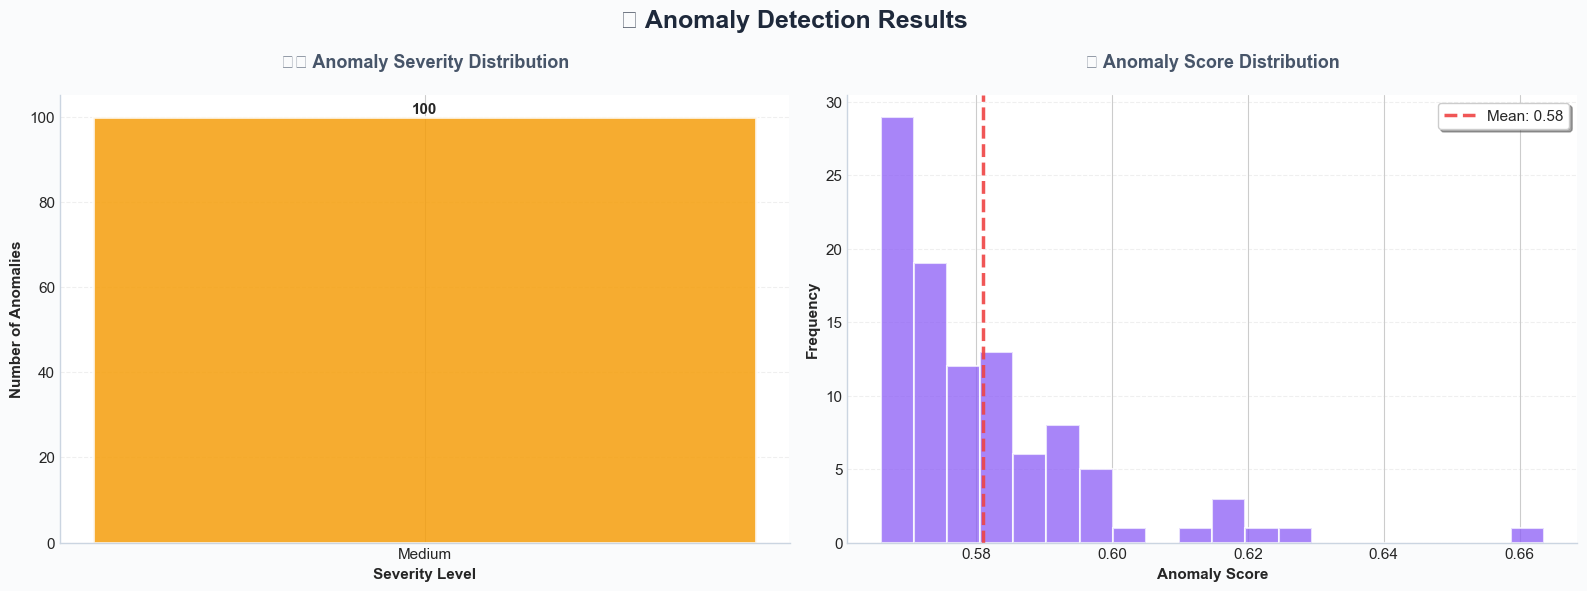

In [41]:
# Visualize anomalies with modern styling
if anomaly_results:
    anomaly_df = pd.DataFrame(anomaly_results)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#fafbfc')
    fig.suptitle('🚨 Anomaly Detection Results', fontsize=18, fontweight='bold', color='#1e293b')
    
    # Severity distribution
    severity_counts = anomaly_df['severity'].value_counts()
    severity_colors = {'High': '#ef4444', 'Medium': '#f59e0b', 'Low': '#10b981'}
    colors = [severity_colors.get(s, '#94a3b8') for s in severity_counts.index]
    
    bars1 = ax1.bar(severity_counts.index, severity_counts.values, 
                    color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    ax1.set_title('⚠️ Anomaly Severity Distribution', fontweight='bold', pad=20, color='#475569', fontsize=13)
    ax1.set_xlabel('Severity Level', fontweight='semibold', fontsize=11)
    ax1.set_ylabel('Number of Anomalies', fontweight='semibold', fontsize=11)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_facecolor('white')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#cbd5e1')
    ax1.spines['bottom'].set_color('#cbd5e1')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Anomaly score distribution
    ax2.hist(anomaly_df['anomaly_score'], bins=20, 
             color='#8b5cf6', alpha=0.75, edgecolor='white', linewidth=1.5)
    ax2.axvline(anomaly_df['anomaly_score'].mean(), 
                color='#ef4444', linestyle='--', linewidth=2.5,
                label=f'Mean: {anomaly_df["anomaly_score"].mean():.2f}', alpha=0.9)
    ax2.set_title('📊 Anomaly Score Distribution', fontweight='bold', pad=20, color='#475569', fontsize=13)
    ax2.set_xlabel('Anomaly Score', fontweight='semibold', fontsize=11)
    ax2.set_ylabel('Frequency', fontweight='semibold', fontsize=11)
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_facecolor('white')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#cbd5e1')
    ax2.spines['bottom'].set_color('#cbd5e1')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No anomalies detected or insufficient data")

## 9️⃣ Product Recommendations

**🎁 Discover cross-sell and upsell opportunities**

In [42]:
# Run product recommendations
print("🎁 Generating Product Recommendations...\n")

# Check if data has product information
if 'product' in df_clean.columns and df_clean.groupby('customer_id').size().mean() > 1:
    # Transaction-level data with products
    recommender = ProductRecommender()
    recommendations = recommender.get_recommendations(df_clean)
else:
    # Aggregated data - no product-level recommendations possible
    print("⚠️ Product recommendations require transaction-level data with product information.")
    print("   Current dataset is aggregated at customer level.")
    recommendations = []

if recommendations:
    rec_df = pd.DataFrame(recommendations)
    
    print("="*60)
    print("🎁 PRODUCT RECOMMENDATION RESULTS")
    print("="*60)
    print(f"\n📊 Total Recommendations: {len(rec_df)}")
    print(f"\n🔝 TOP 10 PRODUCT ASSOCIATIONS:")
    print(rec_df.head(10).to_string(index=False))
    print("="*60)
else:
    print("⚠️ Not enough data for product recommendations. Need transaction-level data with products.")

🎁 Generating Product Recommendations...

⚠️ Product recommendations require transaction-level data with product information.
   Current dataset is aggregated at customer level.
⚠️ Not enough data for product recommendations. Need transaction-level data with products.


In [43]:
# Visualize product recommendations with modern styling
if recommendations:
    # Top 10 recommendations
    top_recs = recommendations[:10]

    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('#fafbfc')

    def rec_label(rec):
        left = rec.get('product_1', rec.get('from_product', 'N/A'))
        right = rec.get('product_2', rec.get('to_product', 'N/A'))
        return f"{left} → {right}"

    product_pairs = [rec_label(r) for r in top_recs]
    lifts = [r.get('lift', 0.0) for r in top_recs]

    # Create horizontal bar chart with gradient colors
    colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(lifts)))
    bars = ax.barh(product_pairs, lifts, color=colors_gradient,
                   alpha=0.85, edgecolor='white', linewidth=2)

    ax.set_xlabel('Lift Score', fontweight='semibold', fontsize=12)
    ax.set_title('🎁 Top Product Recommendation Pairs (by Lift)',
                 fontweight='bold', pad=20, color='#1e293b', fontsize=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')

    # Add value labels
    for bar, lift in zip(bars, lifts):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {lift:.2f}',
                ha='left', va='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No product recommendations available")

⚠️ No product recommendations available


## 🔟 Advanced Analytics & Insights

**📈 Time-series trends and behavioral patterns**

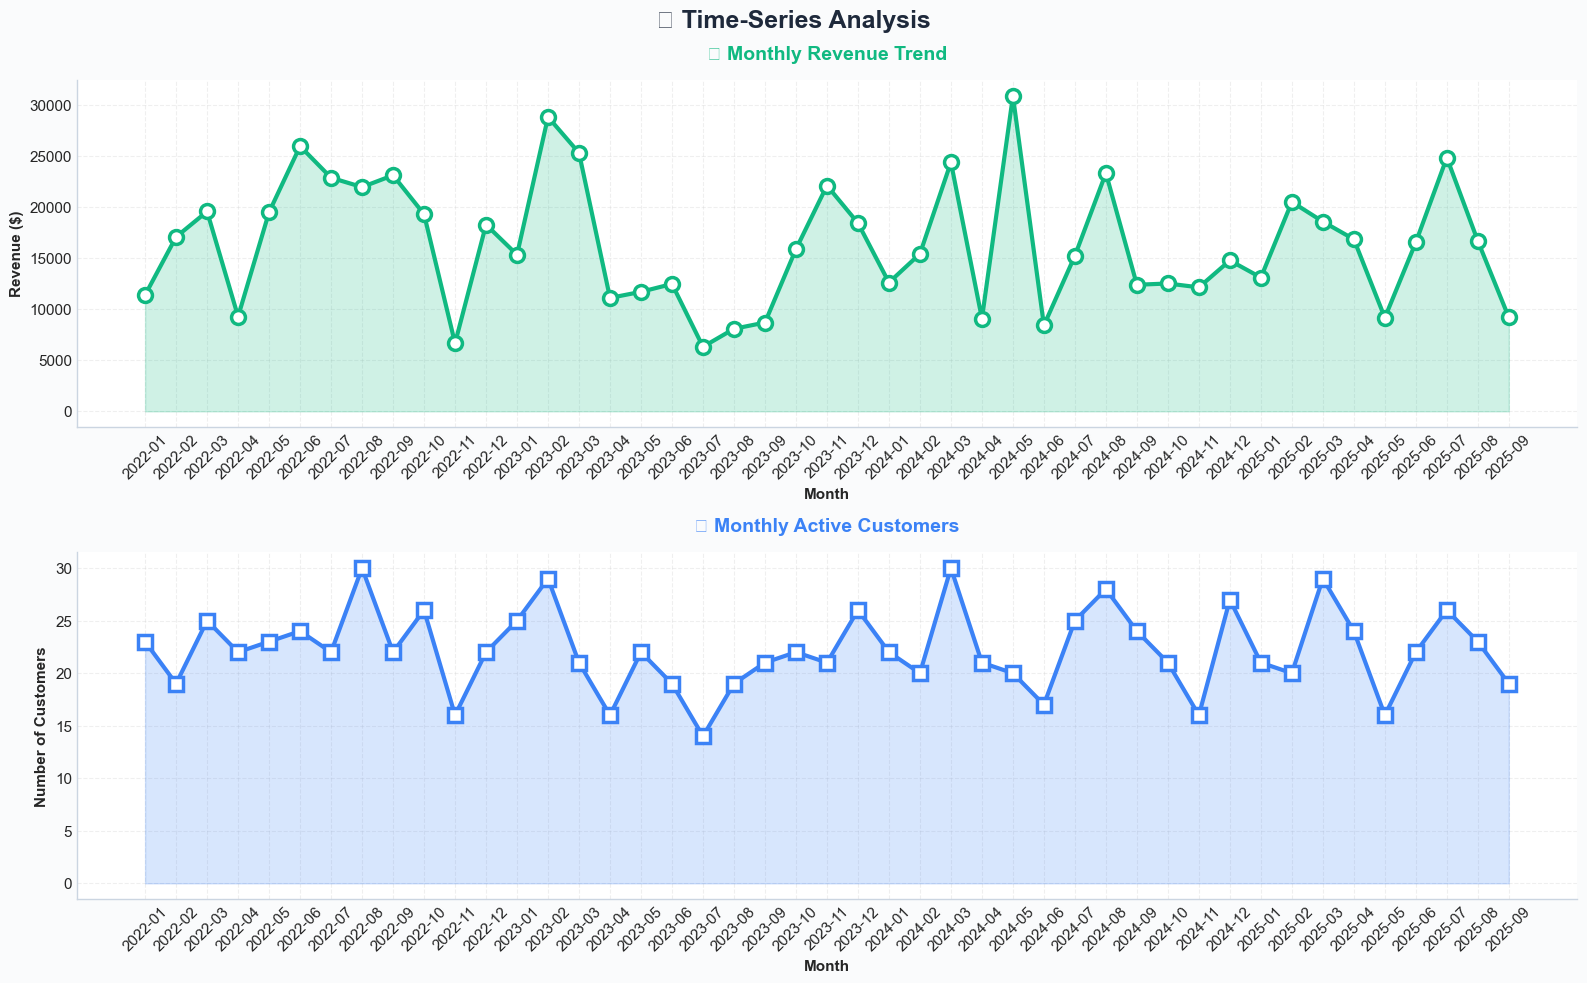

In [44]:
# Time-series analysis with modern styling
# Check if date column exists for time-series analysis
if 'date' in df_clean.columns:
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    df_clean['year_month'] = df_clean['date'].dt.to_period('M')

    # Monthly revenue
    monthly_revenue = df_clean.groupby('year_month')['amount'].sum().reset_index()
    monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

    # Monthly customers
    monthly_customers = df_clean.groupby('year_month')['customer_id'].nunique().reset_index()
    monthly_customers['year_month'] = monthly_customers['year_month'].astype(str)

    # Visualizations with modern styling
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.patch.set_facecolor('#fafbfc')
    fig.suptitle('📈 Time-Series Analysis', fontsize=18, fontweight='bold', color='#1e293b')

    # Revenue trend
    axes[0].plot(monthly_revenue['year_month'], monthly_revenue['amount'], 
                 marker='o', linewidth=3, markersize=10, color='#10b981', 
                 markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#10b981')
    axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue['amount'], 
                         alpha=0.2, color='#10b981')
    axes[0].set_title('💰 Monthly Revenue Trend', fontweight='bold', fontsize=14, pad=15, color='#10b981')
    axes[0].set_ylabel('Revenue ($)', fontweight='semibold', fontsize=11)
    axes[0].set_xlabel('Month', fontweight='semibold', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_facecolor('white')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['left'].set_color('#cbd5e1')
    axes[0].spines['bottom'].set_color('#cbd5e1')

    # Customer trend
    axes[1].plot(monthly_customers['year_month'], monthly_customers['customer_id'],
                 marker='s', linewidth=3, markersize=10, color='#3b82f6',
                 markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#3b82f6')
    axes[1].fill_between(range(len(monthly_customers)), monthly_customers['customer_id'], 
                         alpha=0.2, color='#3b82f6')
    axes[1].set_title('👥 Monthly Active Customers', fontweight='bold', fontsize=14, pad=15, color='#3b82f6')
    axes[1].set_ylabel('Number of Customers', fontweight='semibold', fontsize=11)
    axes[1].set_xlabel('Month', fontweight='semibold', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_facecolor('white')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_color('#cbd5e1')
    axes[1].spines['bottom'].set_color('#cbd5e1')

    plt.tight_layout()
    plt.show()
elif 'LastPurchaseDate' in df_clean.columns:
    # Use LastPurchaseDate if available
    print("📊 Simplified Time-Series Analysis using LastPurchaseDate")
    df_clean['date'] = pd.to_datetime(df_clean['LastPurchaseDate'])
    df_clean['year_month'] = df_clean['date'].dt.to_period('M')
    
    # Customer count by last purchase month
    monthly_customers = df_clean.groupby('year_month').size().reset_index(name='customer_count')
    monthly_customers['year_month'] = monthly_customers['year_month'].astype(str)
    
    # Revenue by last purchase month
    monthly_revenue = df_clean.groupby('year_month')['Monetary'].sum().reset_index()
    monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)
    
    # Visualizations with modern styling
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.patch.set_facecolor('#fafbfc')
    fig.suptitle('📈 Time-Series Analysis (By Last Purchase)', fontsize=18, fontweight='bold', color='#1e293b')

    # Revenue trend
    axes[0].plot(monthly_revenue['year_month'], monthly_revenue['Monetary'], 
                 marker='o', linewidth=3, markersize=10, color='#10b981',
                 markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#10b981')
    axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue['Monetary'], 
                         alpha=0.2, color='#10b981')
    axes[0].set_title('💰 Total Monetary Value by Last Purchase Month', fontweight='bold', fontsize=14, pad=15, color='#10b981')
    axes[0].set_ylabel('Total Monetary ($)', fontweight='semibold', fontsize=11)
    axes[0].set_xlabel('Month', fontweight='semibold', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_facecolor('white')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['left'].set_color('#cbd5e1')
    axes[0].spines['bottom'].set_color('#cbd5e1')

    # Customer trend
    axes[1].plot(monthly_customers['year_month'], monthly_customers['customer_count'],
                 marker='s', linewidth=3, markersize=10, color='#3b82f6',
                 markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#3b82f6')
    axes[1].fill_between(range(len(monthly_customers)), monthly_customers['customer_count'], 
                         alpha=0.2, color='#3b82f6')
    axes[1].set_title('👥 Customer Count by Last Purchase Month', fontweight='bold', fontsize=14, pad=15, color='#3b82f6')
    axes[1].set_ylabel('Number of Customers', fontweight='semibold', fontsize=11)
    axes[1].set_xlabel('Month', fontweight='semibold', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_facecolor('white')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_color('#cbd5e1')
    axes[1].spines['bottom'].set_color('#cbd5e1')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No date column found for time-series analysis")

## 1️⃣1️⃣ Executive Summary & Actionable Insights

**🎯 Key takeaways and recommended actions**

In [45]:
# Generate executive summary with modern formatting
print("\n" + "═"*80)
print(" "*25 + "🎯 EXECUTIVE SUMMARY")
print("═"*80 + "\n")

print("📊 BUSINESS OVERVIEW")
print("─"*80)
print(f"  💰 Total Revenue:              ${total_revenue:,.2f}")
print(f"  👥 Total Customers:            {total_customers:,}")
print(f"  🛒 Total Transactions:         {total_transactions:,}")
print(f"  💵 Average Order Value:        ${avg_order_value:,.2f}")
print(f"  💎 Revenue per Customer:       ${(total_revenue/total_customers):,.2f}\n")

if rfm_available:
    print("🎯 CUSTOMER SEGMENTATION")
    print("─"*80)
    for segment, count in rfm_result['segment_counts'].items():
        percentage = (count / sum(rfm_result['segment_counts'].values())) * 100
        print(f"  • {segment:15s}: {count:4d} customers ({percentage:5.1f}%)")
    print()

if len(churn_df) > 0:
    high_risk = len(churn_df[churn_df['risk_level'] == 'High'])
    high_risk_pct = (high_risk / len(churn_df)) * 100
    print("⚠️ CHURN RISK ANALYSIS")
    print("─"*80)
    print(f"  🚨 High Risk Customers:        {high_risk} ({high_risk_pct:.1f}%)")
    print(f"  📊 Average Churn Probability:  {churn_df['churn_probability'].mean():.1f}%")
    print(f"  💡 Immediate Action Required:  Focus on {high_risk} high-risk customers\n")

if anomaly_results:
    print("🚨 ANOMALY DETECTION")
    print("─"*80)
    print(f"  ⚠️ Unusual Patterns Detected:  {len(anomaly_results)}")
    high_severity = len([a for a in anomaly_results if a['severity'] == 'High'])
    print(f"  🔴 High Severity Anomalies:    {high_severity}")
    print("  💡 Action: Review flagged customers for potential fraud or VIP opportunities\n")

if recommendations:
    print("🎁 PRODUCT RECOMMENDATIONS")
    print("─"*80)
    print(f"  ✅ Product Pairs Identified:   {len(recommendations)}")
    top_3 = recommendations[:3]
    print("  🏆 Top 3 Cross-sell Opportunities:")
    for i, rec in enumerate(top_3, 1):
        left = rec.get('product_1', rec.get('from_product', 'N/A'))
        right = rec.get('product_2', rec.get('to_product', 'N/A'))
        print(f"     {i}. {left} → {right} (Lift: {rec.get('lift', 0.0):.2f}x)")
    print()

print("✨ KEY RECOMMENDATIONS")
print("─"*80)
print("  1️⃣  Launch targeted retention campaign for high-risk customers")
print("  2️⃣  Implement personalized cross-sell offers based on product pairs")
print("  3️⃣  Create VIP program for Champions segment to maximize LTV")
print("  4️⃣  Re-engage At-Risk customers with win-back offers")
print("  5️⃣  Monitor anomalies for fraud prevention and opportunity identification")
print("\n" + "═"*80 + "\n")

print("🎉 Analysis Complete! All insights are ready for action.")
print("📈 Next Steps: Export results and integrate with your CRM/Marketing platforms.")


════════════════════════════════════════════════════════════════════════════════
                         🎯 EXECUTIVE SUMMARY
════════════════════════════════════════════════════════════════════════════════

📊 BUSINESS OVERVIEW
────────────────────────────────────────────────────────────────────────────────
  💰 Total Revenue:              $734,989.23
  👥 Total Customers:            1,000
  🛒 Total Transactions:         1,000
  💵 Average Order Value:        $734.99
  💎 Revenue per Customer:       $734.99

🎯 CUSTOMER SEGMENTATION
────────────────────────────────────────────────────────────────────────────────
  • At-Risk        :  507 customers ( 50.7%)
  • Loyal          :  293 customers ( 29.3%)
  • Champions      :  142 customers ( 14.2%)
  • Low-Value      :   58 customers (  5.8%)

⚠️ CHURN RISK ANALYSIS
────────────────────────────────────────────────────────────────────────────────
  🚨 High Risk Customers:        291 (29.1%)
  📊 Average Churn Probability:  43.3%
  💡 Immediate Act

## 1️⃣2️⃣ Export Results

**💾 Save insights for downstream usage**

In [46]:
# Export all results to JSON format
import json

export_data = {
    'kpis': {
        'total_revenue': float(total_revenue),
        'total_customers': int(total_customers),
        'total_transactions': int(total_transactions),
        'avg_order_value': float(avg_order_value),
        'revenue_per_customer': float(total_revenue / total_customers)
    }
}

if rfm_available:
    export_data['rfm_segments'] = {
        'segment_counts': {k: int(v) for k, v in rfm_result['segment_counts'].items()},
        'revenue_by_segment': {k: float(v) for k, v in rfm_result['revenue_by_segment'].items()}
    }

if len(churn_df) > 0:
    export_data['churn_analysis'] = {
        'total_customers_analyzed': len(churn_df),
        'high_risk_count': int(len(churn_df[churn_df['risk_level'] == 'High'])),
        'avg_churn_probability': float(churn_df['churn_probability'].mean()),
        'risk_distribution': churn_df['risk_level'].value_counts().to_dict()
    }

if anomaly_results:
    export_data['anomalies'] = {
        'total_anomalies': len(anomaly_results),
        'high_severity_count': len([a for a in anomaly_results if a['severity'] == 'High']),
        'anomaly_types': {}
    }

if recommendations:
    export_data['product_recommendations'] = [
        {
            'product_1': r.get('product_1', r.get('from_product', 'N/A')),
            'product_2': r.get('product_2', r.get('to_product', 'N/A')),
            'confidence': float(r.get('confidence', 0.0)),
            'lift': float(r.get('lift', 0.0))
        }
        for r in recommendations[:20]
    ]

# Save to JSON
with open('customer_analytics_results.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("✅ Results exported successfully!")
print("📁 File saved: customer_analytics_results.json")
print(f"📊 Exported {len(export_data)} analysis sections")
print("\n💡 You can now integrate these insights with:")
print("   • CRM platforms (Salesforce, HubSpot)")
print("   • Marketing automation (Mailchimp, Klaviyo)")
print("   • BI tools (Tableau, Power BI)")
print("   • Custom dashboards and applications")

✅ Results exported successfully!
📁 File saved: customer_analytics_results.json
📊 Exported 4 analysis sections

💡 You can now integrate these insights with:
   • CRM platforms (Salesforce, HubSpot)
   • Marketing automation (Mailchimp, Klaviyo)
   • BI tools (Tableau, Power BI)
   • Custom dashboards and applications


---

## 🎉 Congratulations! Your Customer Analytics Dashboard is Complete

### 📊 What You've Accomplished:

✅ **Data Preprocessing** - Intelligent column mapping and cleaning  
✅ **Feature Engineering** - Advanced behavioral metrics  
✅ **KPI Analysis** - Core business metrics visualization  
✅ **RFM Segmentation** - Customer grouping (Champions, Loyal, At-Risk, etc.)  
✅ **Churn Prediction** - Risk assessment for customer retention  
✅ **Anomaly Detection** - Fraud & opportunity identification  
✅ **Product Recommendations** - Cross-sell and upsell opportunities  
✅ **Time-Series Analysis** - Revenue and customer trends  
✅ **Executive Summary** - Actionable insights  
✅ **Data Export** - Ready for integration

---

### 🚀 Next Steps:

1. **Integrate with your systems** - Use the exported JSON with CRM/Marketing platforms
2. **Schedule regular runs** - Automate this notebook to track metrics over time
3. **Act on insights** - Launch campaigns based on segmentation and recommendations
4. **Monitor results** - Track the impact of your data-driven decisions

---

### 💡 Pro Tips:

- Run this analysis **weekly or monthly** for continuous optimization
- Compare results over time to track improvement
- A/B test the recommendations to validate lift estimates
- Share insights with your team for aligned decision-making

---

**Built with ❤️ using Python, Scikit-learn, and Modern Data Science**

*For questions or support, refer to the documentation or contact your analytics team.*

## Explainable AI (SHAP)

Leverage SHAP to explain which engineered features drive customer monetary value, and inspect per-customer attributions with a waterfall plot.

,feature,importance
0,Max_Order,214.832429
1,AOV,210.537082
2,Min_Order,199.102800
3,Recency,0.349068
4,Days_Since_First,0.243202
5,Avg_Qty_Order,0.000000
6,Lifespan_Days,0.000000
7,Frequency,0.000000
8,Total_Items,0.000000
9,Order_Variance,0.000000


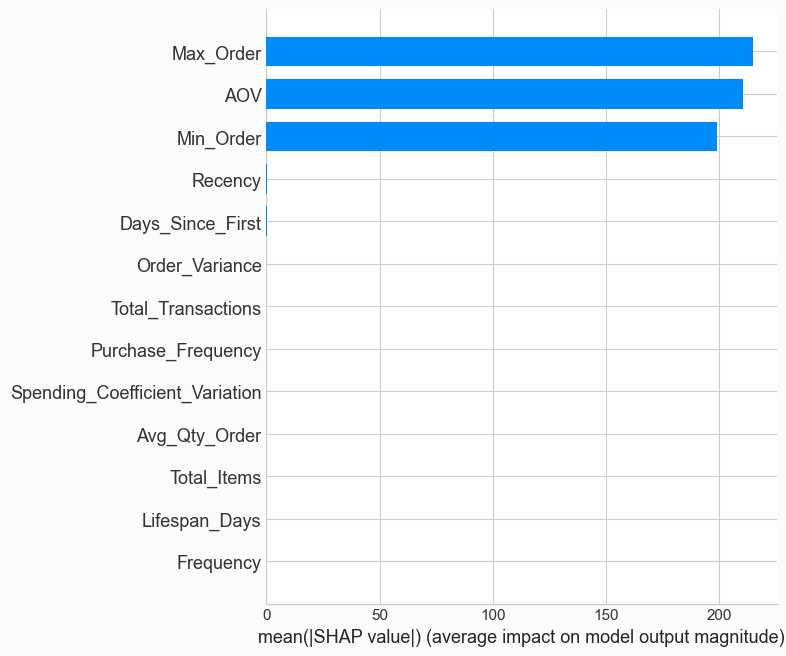

In [47]:
# Install SHAP/matplotlib if missing (no-op when already installed)

import importlib
import os
import subprocess
import sys

for pkg in ["shap", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor

# Access project modules
project_root = os.getcwd()
backend_dir = os.path.join(project_root, "backend")
if project_root not in sys.path:
    sys.path.append(project_root)
if backend_dir not in sys.path:
    sys.path.append(backend_dir)

try:
    models_module = importlib.import_module("backend.ml_models")
except ModuleNotFoundError:
    models_module = importlib.import_module("ml_models")

FeatureEngineer = models_module.FeatureEngineer
DataPreprocessor = models_module.DataPreprocessor

# Load data: prefer existing df/data, else fallback sample
used_sample = False
raw_df = None

if "df" in globals() and isinstance(globals().get("df"), pd.DataFrame):
    raw_df = globals().get("df").copy()
elif "data" in globals() and isinstance(globals().get("data"), pd.DataFrame):
    raw_df = globals().get("data").copy()
else:
    raw_df = pd.read_csv(os.path.join("backend", "sample_data.csv"))
    used_sample = True

def normalize_columns(input_df):
    input_df = DataPreprocessor.auto_detect_columns(input_df)
    alias_map = {
        "date": ["order_date", "OrderDate", "InvoiceDate", "transaction_time", "Date"],
        "amount": ["Total", "Value", "Price", "UnitPrice"],
        "customer_id": ["CustomerID", "Customer ID", "CUST_ID"],
    }
    for target, aliases in alias_map.items():
        if target not in input_df.columns:
            for alias in aliases:
                if alias in input_df.columns:
                    input_df = input_df.rename(columns={alias: target})
                    break
    return input_df

raw_df = normalize_columns(raw_df)
required = {"customer_id", "date", "amount"}
missing = required - set(raw_df.columns)

if missing and not used_sample:
    raw_df = pd.read_csv(os.path.join("backend", "sample_data.csv"))
    raw_df = normalize_columns(raw_df)
    missing = required - set(raw_df.columns)

if missing:
    raise ValueError(f"Missing required columns after mapping: {missing}. Provide columns for customer_id, date, amount.")

raw_df = DataPreprocessor.clean_ecommerce_data(raw_df)
raw_df = DataPreprocessor.calculate_transaction_value(raw_df)
features = FeatureEngineer.merge_all_features(raw_df)

target_col = "Monetary"
id_col = "customer_id"
predictors = [c for c in features.columns if c not in {id_col, target_col}]
X = features[predictors].fillna(0)
y = features[target_col].astype(float)

if len(X) < 10:
    raise ValueError("Need at least 10 customers for a stable SHAP surrogate.")

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
mean_abs = np.abs(shap_values).mean(axis=0)

global_importance = (
    pd.DataFrame({"feature": predictors, "importance": mean_abs})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(global_importance.head(15))
shap.summary_plot(shap_values, X, plot_type="bar", show=True, max_display=15)

Explaining customer_id=C0001


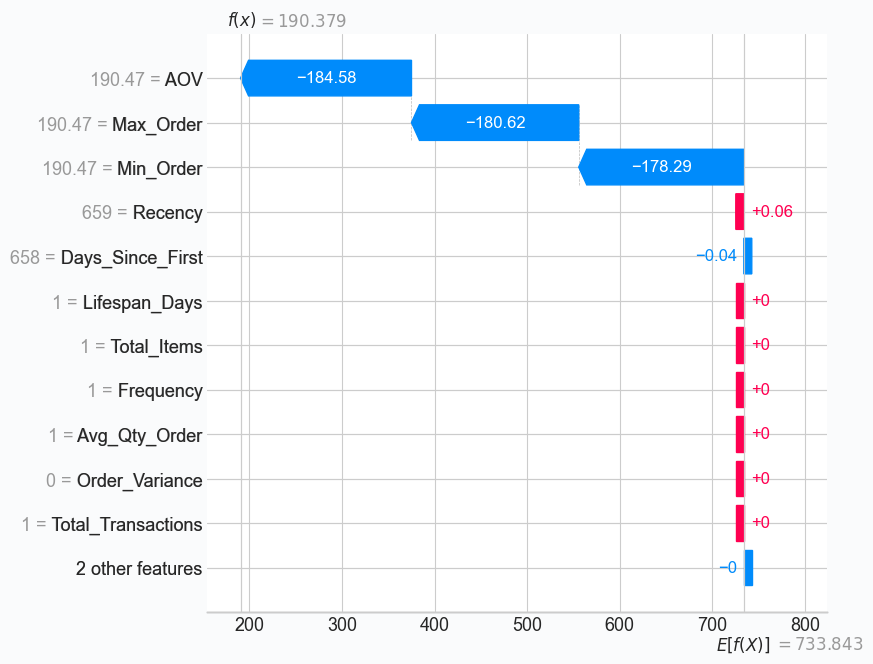

In [48]:
# Local explanation for a specific customer

customer_id_to_explain = features[id_col].iloc[0]



row = features[features[id_col] == customer_id_to_explain]

row_X = row[predictors].fillna(0)



local_shap = explainer.shap_values(row_X)

exp = shap.Explanation(

    values=local_shap[0],

    base_values=explainer.expected_value if np.ndim(explainer.expected_value) == 0 else explainer.expected_value[0],

    data=row_X.iloc[0],

    feature_names=predictors,

)



print(f"Explaining customer_id={customer_id_to_explain}")

shap.plots.waterfall(exp, max_display=12, show=True)